# EDA Titanic. **Trabajo realizado por:**

* Salvador Alfonso Ruiz Guerrero

## Cargar librerías

In [56]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import matplotlib.pyplot as plt
from scipy.stats import chi2_contingency, fisher_exact # Usaré solo chi2_contingency
from statsmodels.stats.contingency_tables import Table # El test exacto de Fisher de stats solo soporta tablas 2x2. Calculo la tabla y el test con statsmodels
import statsmodels.api as sm  # Para hacer Regresión Logística

from sklearn.preprocessing import StandardScaler  # Para estandarizar antes de Regresión Lógistica y facilitar convergencia

## 1. Carga y comprensión inicial de los datos

### Carga de datos



En este análisis exploratorio de datos (EDA), trabajaremos con el conjunto de datos ***Titanic***.

Es uno de los datasets más conocidos, el cual podemos encontrar en la plataforma Kaggle. Este dataset contiene información sobre los pasajeros del Titanic, el transatlántico británico que se hundió en abril de 1912 durante su viaje inaugural desde Southampton a Nueva York. Entre la información almacenada se encuentran la edad, género, características socio-económicas de los pasajeros y si sobrevivieron o no al naufragio.

In [57]:
datos = pd.read_csv('titanic.csv',
                    na_values=['', 'NA', 'null', 'N/A']  # Lista de valores que serán tratados como faltantes
)

datos

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


### Descripción de las variables. Variable objetivo (respuesta, dependiente, label).

Las variables que contiene el dataset son:

- **PassengerId**: identificador único del pasajero.

- **Survived**: si el pasajero sobrevivió al naufragio, codificada como 0 (no) y 1 (sí). Esta es la variable respuesta que interesa predecir.

- **Pclass**: clase a la que pertenecía el pasajero: 1ª, 2ª o 3ª, codificadas como 1, 2 y 3.

- **Name**: nombre del pasajero.

- **Sex**: sexo del pasajero.

- **Age**: edad del pasajero.

- **SibSp**: número de cónyuges, hermanos, hermanas, hermanastros o hermanastras en el barco.

- **Parch**: número de padres e hijos en el barco.

- **Ticket**: identificador del billete.

- **Fare**: precio pagado por el billete.

- **Cabin**: identificador del camarote asignado al pasajero.

- **Embarked**: puerto en el que embarcó el pasajero (Southampton -Inglaterra-, Cherburgo -Francia- y Queenstown -actual Cobh, en Irlanda-)

La **variable objetivo / variable respuesta** es **Survived**, codificada como 0 (no) y 1 (sí), es dicotómica y en este caso es si el pasajero sobrevivió o no al naufragio del Titanic. Vamos a entrenar un modelo de regresión logística para ver si somos capaces de predecir con el mayor acierto posible nuestra variable respuesta.

### Objetivo del estudio

El objetivo de este análisis es identificar y comprender los datos disponibles en la base de datos **titanic** que hemos comentado, con el fin posterior de predecir con el mayor acierto quiénes sobrevivieron y quiénes no.

En primer lugar, revisaremos las variables incluidas en el conjunto de datos. Estas variables independientes (features, explicativas) representan diferentes aspectos de los pasajeros. Al comprender el significado y la naturaleza de estas variables, podremos evaluar cómo se relacionan con la variable dependiente (label, respuesta, objetivo), que en este caso es haber sobrevivido o no al naufragio del Titanic.



### Exploración preliminar


Vamos a comenzar examinando la estructura general de los datos. Podemos observar que la base presenta 891 individuos y 12 variables. De la base de datos podemos destacar lo siguiente:
- La mayoría de los pasajeros viajaban en tercera clase.
- Más del 60% de los viajeros no sobrevivió.
- La mayoría de pasajeros tenía entre 20 y 38 años.
- Elevada desviación entre los precios de los boletos
- La mayoría de los pasajeros viajaban solos

In [58]:
print("\n --------- Número de indiviuos y variables --------- \n")
print(f'El número de individuos es: {datos.shape[0]}')
print(f'El número de variables es: {datos.shape[1]}\n')

print("\n --------- Primeras filas de la base de datos --------- \n")
print(datos.head())
#print(datos.tail())
print("\n")

print("\n --------- Información sobre la base de datos --------- \n")
print(datos.info())
print("\n")

print("\n --------- Sumario de la base de datos --------- \n")
print(datos.describe())
print("\n")

print("\n --------- Cantidad de nulos por variable de la base de datos --------- \n")
print(datos.isnull().sum())
print("\n")

print("\n --------- Tipos de las variables de la base de datos --------- \n")
print(datos.dtypes)
print("\n")


 --------- Número de indiviuos y variables --------- 

El número de individuos es: 891
El número de variables es: 12


 --------- Primeras filas de la base de datos --------- 

   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833 

## 2. Limpieza y adecuación de los datos

A continuación, vamos a limpiar la base de datos. Lo primero que vamos a hacer es eliminar las variables Name, PassengerId y Ticket, pues no nos dan información relevante sobre los individuos. Luego hemos eliminado los datos duplicados y finalmente, hemos puesto etiquetas a aquellas variables categóricas codificadas numericamente.

In [59]:
# Identificar duplicados
duplicados = datos.duplicated().sum()
print(f"Número de entradas duplicadas: {duplicados}\n")
print(datos[datos.duplicated()])

# Eliminar duplicados si existen
datos = datos.drop_duplicates()

# Eliminamos las variables no útiles: Name, PassengerId y Ticket
datos.drop(columns=['Name', 'PassengerId','Ticket'], inplace=True)

# Para evitar warnings y asegurarnos que no cambiamos datos sin querer (hayamos obtenido datos filtrando otro dataframe y sea una vista)
datos = datos.copy()

# Definir los mapeos de etiquetas para las variables categóricas
mappings = {
    "Pclass": {1: "1ªclase", 2: "2ªclase", 3: "3ªclase"},
    "Survived": {0: "No sobrevivió", 1: "Sobrevivió"},
}

# Aplicar mapeo y conversión a categoría directamente
for col, mapping in mappings.items():
    if col in datos.columns:
        # Usar una cadena de pasos clara y funcional
        datos[col] = datos[col].map(mapping).astype("category")

print(datos.dtypes)  # Verifica que las columnas sean categóricas

Número de entradas duplicadas: 0

Empty DataFrame
Columns: [PassengerId, Survived, Pclass, Name, Sex, Age, SibSp, Parch, Ticket, Fare, Cabin, Embarked]
Index: []
Survived    category
Pclass      category
Sex           object
Age          float64
SibSp          int64
Parch          int64
Fare         float64
Cabin         object
Embarked      object
dtype: object


## 3. Análisis de valores faltantes

Como observamos, las variables que presentan valores faltantes son Cabin, Age y Embarked, todos ellos con tipo NA.
- Debido a la elevada cantidad de datos nulos de Cabin (74% de los datos), vamos a tomar la decisión de eliminar dicha variable, pues no consideramos que proporcione información relevante.
- Las variables Edad y Embarked presentan muchos menos valores faltantes, en concreto un 13'52% y un 0'26%. Es por ello que consideramos imputar los datos nulos de la variable Edad con la mediana (por ser numérica) y la variable Embarked con la moda (por ser categórica).


 --------- Cantidad de valores en blanco por variable --------- 

Survived      0
Pclass        0
Sex           0
Age         177
SibSp         0
Parch         0
Fare          0
Cabin       687
Embarked      2
dtype: int64


El porcentaje de valores faltantes de la variable Edad es: 19.87
El porcentaje de valores faltantes de la variable Cabin es: 77.1
El porcentaje de valores faltantes de la variable Embarked es: 0.22




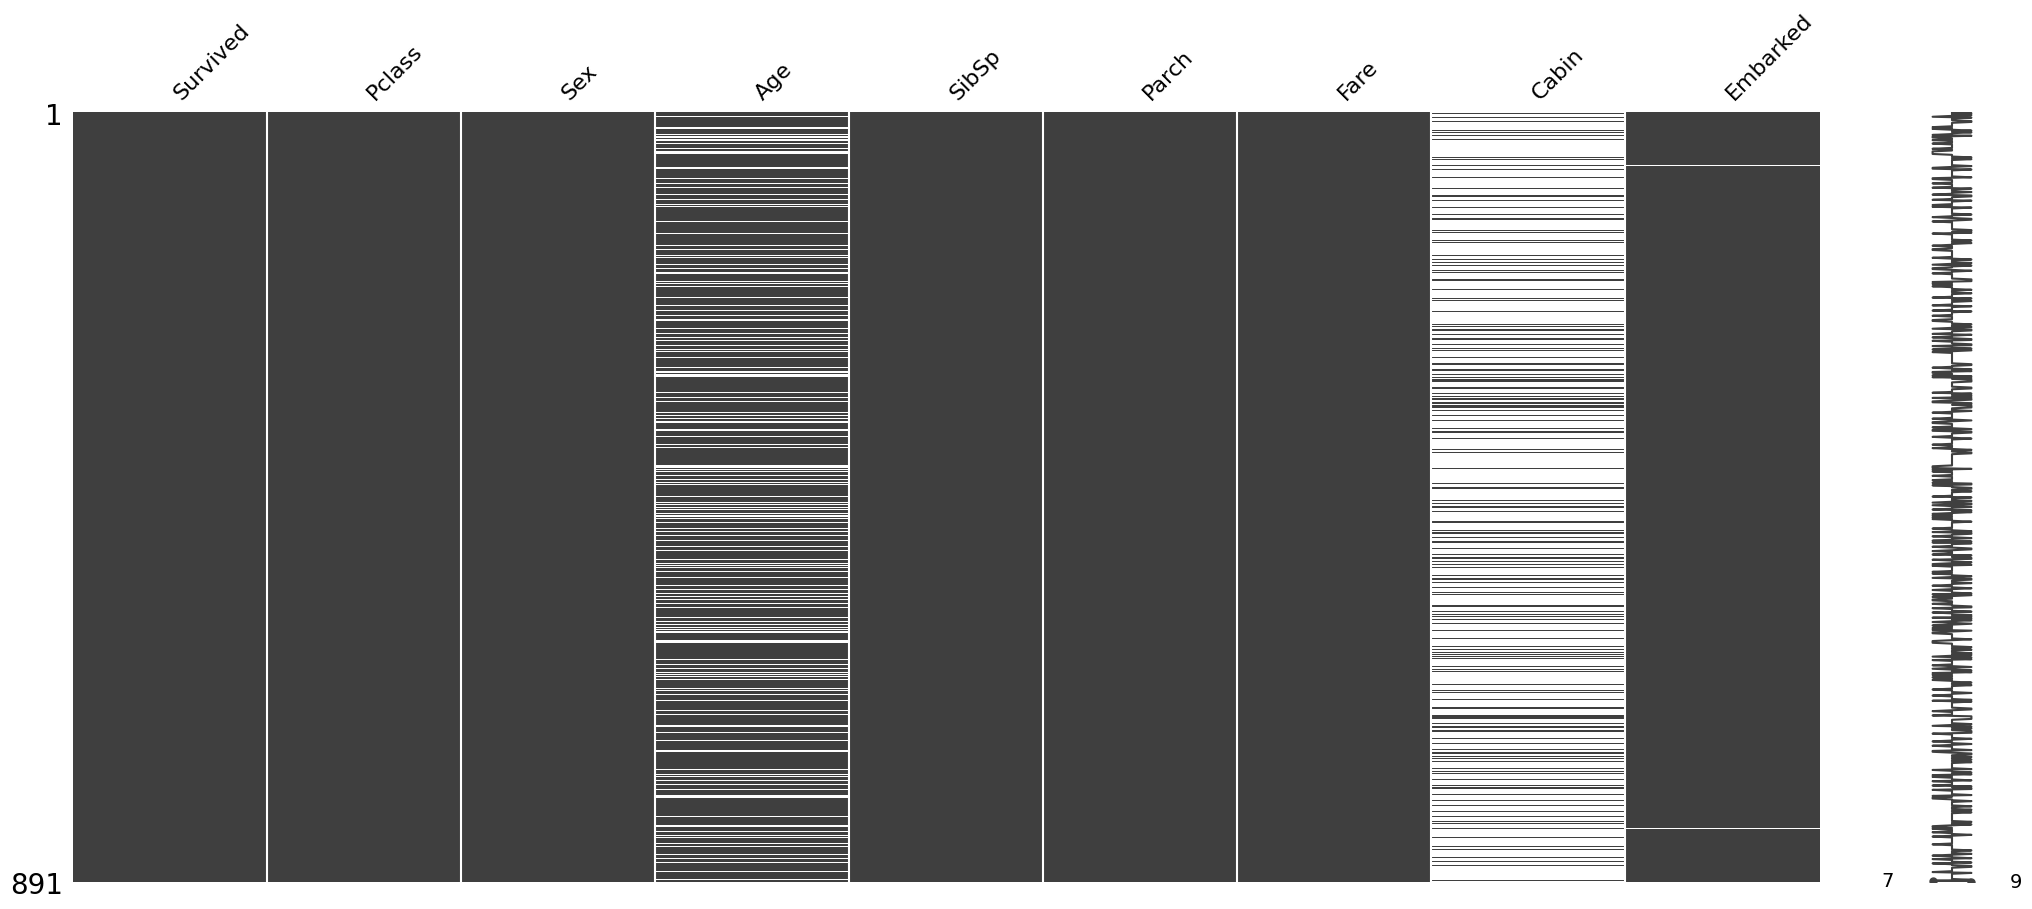

In [60]:
print("\n --------- Cantidad de valores en blanco por variable --------- \n")
print(datos.isnull().sum())
print("\n")

# Porcentaje de valores faltantes por variable
edadfaltantes = round((datos['Age'].isnull().sum()/len(datos))*100,2)
cabinfaltantes = round((datos['Cabin'].isnull().sum()/len(datos))*100,2)
embarkfaltantes = round((datos['Embarked'].isnull().sum()/len(datos))*100,2)
print(f'El porcentaje de valores faltantes de la variable Edad es: {edadfaltantes}')
print(f'El porcentaje de valores faltantes de la variable Cabin es: {cabinfaltantes}')
print(f'El porcentaje de valores faltantes de la variable Embarked es: {embarkfaltantes}')
print("\n")

import missingno as msno
msno.matrix(datos)
plt.show()

# Eliminamos la variable Cabin
datos.drop(columns=['Cabin'], inplace=True)

# Rellenamos los datos en blanco de la variable Edad con los valores de la mediana
datos['Age'] = datos['Age'].fillna(datos['Age'].median())

# Rellenamos los datos en blanco de la variable Embarked Embarked con los valores de la moda
datos['Embarked'] = datos['Embarked'].fillna(datos['Embarked'].mode()[0])

## 4. Feature engineering


Para predecir la variable Survived, consideramos crear dos variables nuevas:
- Age_group: la cual nos indica si la persona era un:
  - Niño (entre 0 y 12 años)
  - Adolescentes (entre 12 y 18 años)
  - Joven Adulto (entre 18 y 30 años)
  - Adulto (entre 30 y 50 años)
  - Senior (entre 50 y 100 años)
- Is_alone: la cual nos indica si fue solo o si viaja con familia.

In [61]:
# Añadimos la variable Edad según su etapas vitales
edades=[0, 12, 18, 30, 50, 100]
etapas=['Niños', 'Adolescentes', 'Joven Adulto', 'Adulto', 'Senior']
datos['Age_group'] = pd.cut(datos['Age'], bins=edades, labels=etapas, right=False)
#datos['Age_group'] = datos['Age_group'].map({'Niños': 1, 'Adolescentes': 2, 'Joven Adulto':3, 'Adulto': 4, 'Senior': 5})

# Añadimos la variable Is_Alone según su iba solo o no
datos['Is_alone'] = np.where((datos['SibSp'] + datos['Parch'] + 1) == 1, "Alone", "Not Alone")

## 5. Análisis univariado

Hemos comenzado con un descriptiva de las variables categóricas y de las numéricas.

- Para las variables categóricas hemos calculado:
   - Frecuencia absoluta y relativa
   - Ratio entre clases más frecuente y menos frecuente
   - Número de categorías únicas
   - Categoría con más frecuencia y su porcentaje
- Para las variables númericas hemos calculado:
   - Media, mediana y moda
   - Percentiles
   - Varianza y desviación estándar
   - Rango intercuartílico
   - Asimetría y curtosis

Además, hemos considerado diferentes gráficos para observar el comportamiento de las variables.

- Para las variables categóricas hemos calculado:
   - Histograma
   - Gráfico de densidad
   - Boxplot
- Para las variables númericas hemos calculado:
   - Diagrama de barras
   - Diagrama circular

### Variables cualitativas (categóricas)

In [62]:
# Descriptiva
variables_cat = ['Survived','Pclass', 'Sex', 'Embarked', 'Age_group', 'Is_alone']

for var in variables_cat:

   frecuencia_absoluta = datos[var].value_counts()  # Frecuencia absoluta
   frecuencia_relativa = round(datos[var].value_counts(normalize=True) * 100,2)  # Frecuencia relativa
   ratio_clases = frecuencia_absoluta.max() / frecuencia_absoluta.min()  # Ratio entre clases más frecuente y menos frecuente
   cardinalidad = datos[var].nunique()  # Número de categorías únicas
   categoria_dominante = frecuencia_absoluta.idxmax()  # Categoría con más frecuencia
   porcentaje_dominante = frecuencia_relativa.max()  # Porcentaje de la categoría dominante

   estadisticas = {
      "Métrica": ["Variable","Frec. Absoluta", "Frec. Relativa (%)", "Ratio de Clases",
                "Cardinalidad", "Categoría Dominante", "Porcen. Dominante (%)"],
      "Valor": [
          var,
          str(frecuencia_absoluta.to_dict()),  # Convertimos en string para mostrar bien en la tabla
          str(frecuencia_relativa.to_dict()),
          ratio_clases,
          cardinalidad,
          categoria_dominante,
          porcentaje_dominante
          ]
      }
   tabla_estadisticas = pd.DataFrame(estadisticas)
   print(tabla_estadisticas)
   print("\n")

                 Métrica                                          Valor
0               Variable                                       Survived
1         Frec. Absoluta      {'No sobrevivió': 549, 'Sobrevivió': 342}
2     Frec. Relativa (%)  {'No sobrevivió': 61.62, 'Sobrevivió': 38.38}
3        Ratio de Clases                                       1.605263
4           Cardinalidad                                              2
5    Categoría Dominante                                  No sobrevivió
6  Porcen. Dominante (%)                                          61.62


                 Métrica                                              Valor
0               Variable                                             Pclass
1         Frec. Absoluta   {'3ªclase': 491, '1ªclase': 216, '2ªclase': 184}
2     Frec. Relativa (%)  {'3ªclase': 55.11, '1ªclase': 24.24, '2ªclase'...
3        Ratio de Clases                                           2.668478
4           Cardinalidad                  

Supervivencia: Hay unas pocas personas más que no sobrevivieron en el conjunto de datos (549) respecto con los que si sobrevivieron (342).

Distribución por clase: Encontramos el doble de personas de 3ª clase (491) que de 1ª clase (216), y el doble de 1ª clase que de 2ª clase (184). Este factor puede indicar una sobre-representación de la 3ª clase frente al resto a la hora de estudiar la supervivencia.

Distribución por sexo: Hay una mayor cantidad de hombres en el conjunto de datos (577) en comparación con mujeres (314). Esto puede indicar una posible sobre-representación masculina en el estudio de los factores de riesgo de la supervivencia.

Distribución por embarque: Encontramos casi el cuatriple de personas que embarcaron en Southampton (646) que en Cherbourg (168), y el triple de las que embarcaron en Cherbourg que en Queenstown (77). Este factor puede indicar una sobre-representación de las personas que embarcaron en Southampton para predecir la supervivencia de los pasajeros.

Distribución por grupo de edad: Hay una mayor cantidad de jóvenes adultos y adultos (448 y 256) en comparación con los grupos senior, niños y adolescentes (74, 68 y 45). Esto puede indicar una posible sobre-representación de los grupos jóvenes adultos y adultos en el estudio de los factores de riesgo de la supervivencia.

Distribución por presencia o ausencia de compañia: Hay ligeramente más personas que fueron solas (537) en comparación con las que fueron acompañadas (354).

### Variables cuantitativas

Comentarios sobre el rango de valores:
  * **Age**: Entre 0.42 y 80. Un rango muy amplio. Media y mediana sobre los 30 años. El 75% presenta menos de 35 años.
  * **SibSp**: Máximo de 8 es un claro outlier que debe analizarse.
  * **Parch**: Máximo de 6. El 75% presenta uno o ningun padre/hijo.
  * **Fare**: Máximo de 512 es un claro outlier que debe analizarse. La media es de 34 libras, valor máximo que ha pagado el 75% de los viajeros.

In [63]:
variables_num = ['Age', 'SibSp', 'Parch', 'Fare']

for var in variables_num:
   estadisticas = {
      "Métrica": ["Variable","Máximo", "Mínimo", "Media", "Mediana", "Moda", "Percentil 25", "Percentil 50", "Percentil 75",
                "Varianza", "Desv estándar", "IQR", "Asimetría", "Curtosis"],
      "Valor": [
          var,
          datos[var].max(), # Máximo
          datos[var].min(), # Mínimo
          round(np.mean(datos[var]),5),  # Media
          round(np.median(datos[var]),5),  # Mediana
          round(stats.mode(datos[var])[0],5), # Moda
          round(np.percentile(datos[var], 25),5),  # Percentil 25
          round(np.percentile(datos[var], 50),5),  # Percentil 50 (Mediana)
          round(np.percentile(datos[var], 75),5),  # Percentil 75
          round(np.var(datos[var], ddof=1),5),  # Varianza
          round(np.std(datos[var], ddof=1),5),  # Desviación estándar
          round(np.percentile(datos[var], 75)-np.percentile(datos[var], 25),5),  # Rango intercuartílico
          round(stats.skew(datos[var]),5),  # Asimetría
          round(stats.kurtosis(datos[var]),5)  # Curtosis
          ]
      }
   tabla_estadisticas = pd.DataFrame(estadisticas)
   print(tabla_estadisticas)
   print("\n")

          Métrica     Valor
0        Variable       Age
1          Máximo      80.0
2          Mínimo      0.42
3           Media  29.36158
4         Mediana      28.0
5            Moda      28.0
6    Percentil 25      22.0
7    Percentil 50      28.0
8    Percentil 75      35.0
9        Varianza  169.5125
10  Desv estándar   13.0197
11            IQR      13.0
12      Asimetría   0.50939
13       Curtosis   0.98158


          Métrica     Valor
0        Variable     SibSp
1          Máximo         8
2          Mínimo         0
3           Media   0.52301
4         Mediana       0.0
5            Moda         0
6    Percentil 25       0.0
7    Percentil 50       0.0
8    Percentil 75       1.0
9        Varianza   1.21604
10  Desv estándar   1.10274
11            IQR       1.0
12      Asimetría   3.68913
13       Curtosis  17.77351


          Métrica    Valor
0        Variable    Parch
1          Máximo        6
2          Mínimo        0
3           Media  0.38159
4         Mediana    

### Análisis gráfico variables categóricas

#### Diagramas de barras

Como podemos observar, la mayoría de los pasajeros viajaban en tercera clase y solos. Además, había el doble de hombres que mujeres. Una gran cantidad, embarcó en Southampton. El grupo de edad más presente eran los jóvenes adultos, seguido de los adultos.

La cantidad que no sobrevivió es ligeramente mayor a la que si sobrevivió.

Sin embargo, una minoría embarcó en Queenstown, el grupo de edad menos presente fueron los adolescentes y la clase más ausente fue la segunda.

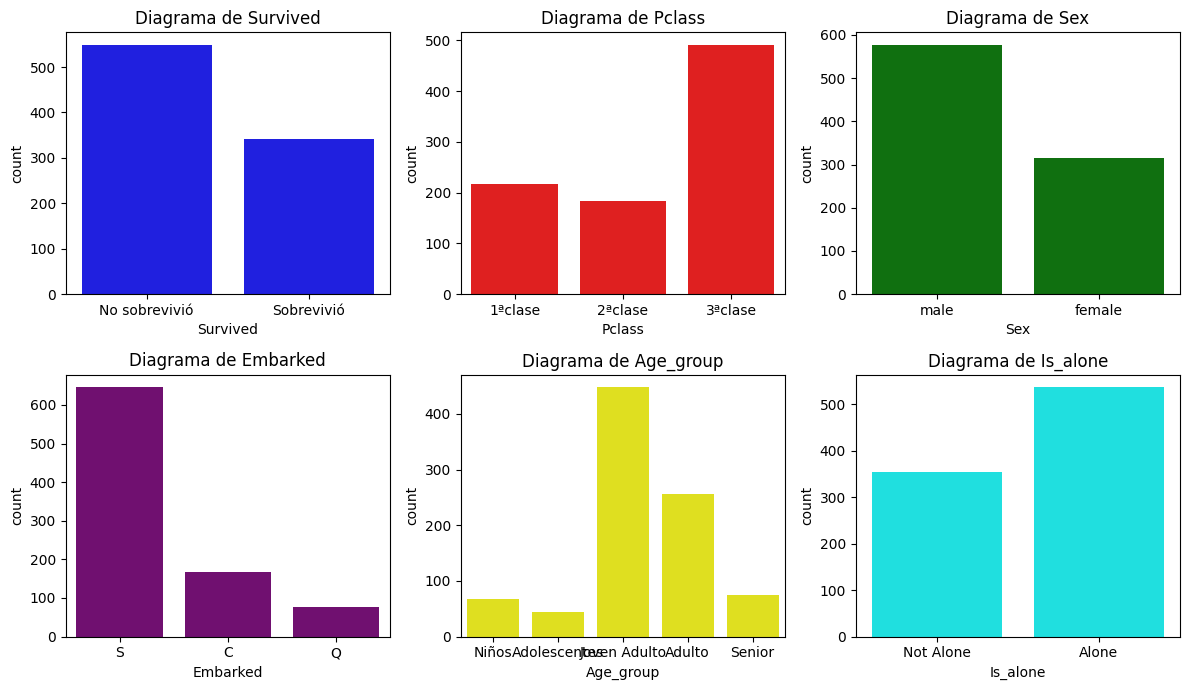

In [64]:
# Crear figura con dos subgráficos
plt.figure(figsize=(12, 7))

# Poner las gráficas en subgráficos
plt.subplot(2, 3, 1)
sns.countplot(x='Survived', data=datos, color='blue')
plt.title('Diagrama de Survived')

plt.subplot(2, 3, 2)
sns.countplot(x='Pclass', data=datos, color='red')
plt.title('Diagrama de Pclass')

plt.subplot(2, 3, 3)
sns.countplot(x='Sex', data=datos, color='green')
plt.title('Diagrama de Sex')

plt.subplot(2, 3, 4)
sns.countplot(x='Embarked', data=datos, color='purple')
plt.title('Diagrama de Embarked')

plt.subplot(2, 3, 5)
sns.countplot(x='Age_group', data=datos, color='yellow')
plt.title('Diagrama de Age_group')

plt.subplot(2, 3, 6)
sns.countplot(x='Is_alone', data=datos, color='cyan')
plt.title('Diagrama de Is_alone')

# Ajustar el espaciado entre los subgráficos
plt.tight_layout()

# Mostrar los gráficos
plt.show()

### Análisis gráfico variables cuantitativas

#### Boxplots

Analizando los box plots, se pueden observar varios valores atípicos (outliers) significativos en diferentes variables:

En el número de hermanos/conyuges ('SibSp'), se observa un individuo que constaba de 8 hermanos/conyuges. Esto ya lo comentamos en la descriptiva no gráfica.

En el precio del ticket ('Fare'), se identifica un valores atípico de más de 500 libras. Este caso representaría uno de los mejores camarotes de primera clase. Esto ya lo comentamos en la descriptiva no gráfica.


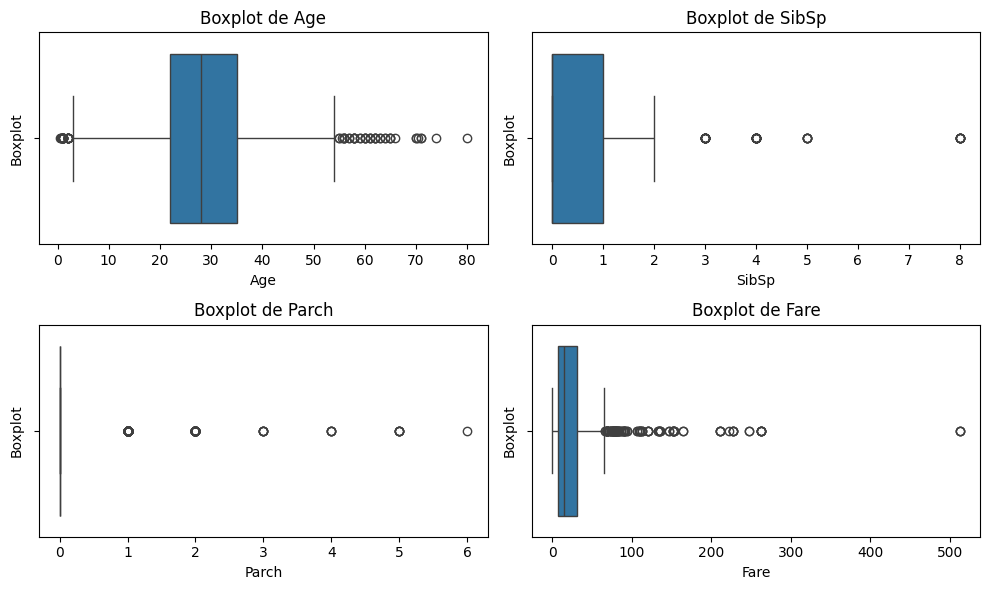

In [65]:
variables_num = ['Age', 'SibSp', 'Parch', 'Fare']

plt.figure(figsize=(10, 6))

for i, var in enumerate(variables_num):
    # Crear el histograma (usamos Seaborn)
    plt.subplot(2, 2, i+1)
    sns.boxplot(x=datos[var])
    plt.title(f'Boxplot de {var}')
    plt.xlabel(var)
    plt.ylabel('Boxplot')

plt.tight_layout()
plt.show()

#### Outliers

Como ya habiamos comentado en los boxplots, las variables presentan una gran cantidad de outliers, destacando la variable Parch que consta de un cuarto de la base de datos de valores atípicos. Debido al elevado numero en cada variable, solo vamos a eliminar los individuos que tienen valores extremos como los que encontramos en SibSp de 8 hermanos/cónyugues y en Fare de más de 500 libras.

In [66]:
variables_num = ['Age', 'SibSp', 'Parch', 'Fare']

# Inicializar un diccionario para almacenar los índices de los outliers
outlier_indices = {}

# Identificar los outliers usando el método de Tukey
for var in variables_num:
    # Calcular los cuartiles y el rango intercuartílico (IQR)
    Q1 = datos[var].quantile(0.25)
    Q3 = datos[var].quantile(0.75)
    IQR = Q3 - Q1

    # Límites inferior y superior
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Identificar índices de los outliers
    outliers = datos[(datos[var] < lower_bound) | (datos[var] > upper_bound)].index.tolist()
    outlier_indices[var] = outliers

# Imprimir el total de outliers por variable
print("Total de outliers por variable:")
for var, indices in outlier_indices.items():
    print(f"{var}: {len(indices)}")

# Imprimir los índices de los outliers por variable
print("\nÍndices de outliers por variable:")
for var, indices in outlier_indices.items():
    print(f"{var}: {indices}")




# Combinar todos los índices de outliers en una sola lista
all_outlier_indices = [idx for indices in outlier_indices.values() for idx in indices] # Una list comprehension anidada, que no hemos visto

# Contar la frecuencia de cada índice
from collections import Counter
outlier_counts = Counter(all_outlier_indices)

# Filtrar los índices que se repiten más de una vez
repeated_outliers = {idx: count for idx, count in outlier_counts.items() if count > 1} # Esto es un dictionary comprehension, que no hemos visto

# Imprimir los resultados
if repeated_outliers:
    print("Índices que se repiten como outliers en más de una variable:")
    for idx, count in repeated_outliers.items():
        print(f"Índice: {idx}, Repeticiones: {count}")
else:
    print("No hay índices que se repitan como outliers en más de una variable.")


datos.drop(index=datos["Fare"].idxmax(), inplace=True)
datos.drop(index=datos["SibSp"].idxmax(), inplace=True)


Total de outliers por variable:
Age: 66
SibSp: 46
Parch: 213
Fare: 116

Índices de outliers por variable:
Age: [7, 11, 15, 16, 33, 54, 78, 94, 96, 116, 119, 152, 164, 170, 172, 174, 183, 195, 205, 232, 252, 268, 275, 280, 297, 305, 326, 340, 366, 381, 386, 438, 456, 467, 469, 479, 483, 487, 492, 493, 530, 545, 555, 570, 587, 625, 626, 630, 642, 644, 647, 659, 672, 684, 694, 745, 755, 772, 788, 803, 824, 827, 829, 831, 851, 879]
SibSp: [7, 16, 24, 27, 50, 59, 63, 68, 71, 85, 88, 119, 159, 164, 171, 176, 180, 182, 201, 229, 233, 261, 266, 278, 324, 341, 374, 386, 409, 480, 485, 541, 542, 634, 642, 683, 686, 726, 787, 792, 813, 819, 824, 846, 850, 863]
Parch: [7, 8, 10, 13, 16, 24, 25, 27, 43, 50, 54, 58, 59, 63, 65, 68, 71, 78, 86, 88, 93, 97, 98, 102, 118, 119, 124, 128, 136, 140, 145, 147, 148, 153, 155, 159, 160, 164, 165, 166, 167, 171, 172, 175, 176, 180, 182, 183, 184, 188, 193, 197, 201, 205, 229, 233, 237, 247, 248, 251, 254, 255, 259, 261, 262, 266, 268, 272, 273, 278, 279, 297,

## 6. Análisis Bivariado

### Variables categóricas

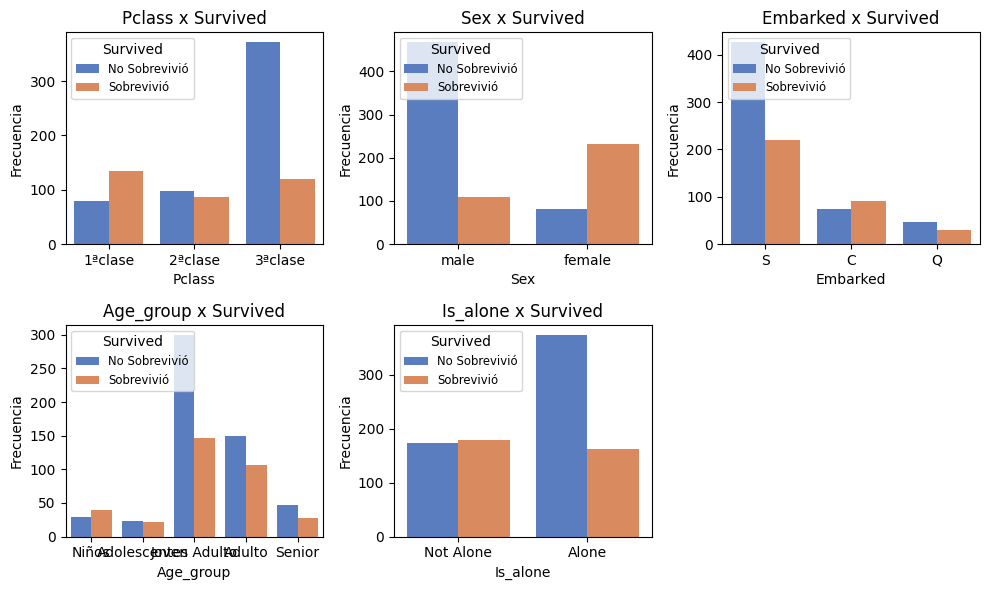

In [67]:
categoricas_vars = ['Pclass', 'Sex', 'Embarked', 'Age_group', 'Is_alone']

# Configurar la figura para los gráficos de barras
plt.figure(figsize=(10, 6))

# Crear gráficos de barras para cada variable cualitativa
for i, var in enumerate(categoricas_vars, 1):
    plt.subplot(2, 3, i)  # 2 filas, 3 columnas (ajustar según sea necesario) # Una manera de especificar el gráfico por índice que no hemos visto
    sns.countplot(x=var, hue='Survived', data=datos, palette='muted')    # Aquí lo importante es en hue indicar la variable respuesta
    plt.title(f'{var} x Survived')
    plt.xlabel(var)
    plt.ylabel('Frecuencia')
    plt.legend(title='Survived', loc='upper left', fontsize='small', labels=['No Sobrevivió', 'Sobrevivió'])

plt.tight_layout()
plt.show()

Se observan varias diferencias entre las categorías de las variables en cuanto a la supervivencia.

- **Pclass**. Los grupos de segunda y tercera clase, la mayoría no sobrevivieron, habiendo una gran cantidad de fallecidos en la tercera clase. Sin embargo, casi el doble viajeros de primera clase si pudieron sobrevivir.
- **Sex**. La proporción de enfermedad es mayor en hombres que en mujeres. En los hombres, la mayoría de los pasajeros no sobrevivieron, mientras que en las mujeres la mayoría si sobrevivieron.
- **Embarked**. Tanto los que embarcaron en Southampton como en Queenstown fallecieron más que sobrevivieron, siendo más significativo en Southampton. Sin embargo, Cherbourg sobrevivieron unos pocos más.
- **Age_group**. Las etapas de edad más altas (joven adulto, adulto y anciano) presentan mas fallecidos, siendo más signficativo en los jovenes adultos. Sin embargo, se salvaron más niños y de adolescentes hubo la misma cantidad de supervivientes que no supervivientes.
- **Is_alone**. De aquellos que fueron acompañados, la mitad sobrevivieron, mientras que en aquellos que fueron solos, el doble de personas murieron.

Todas las variables parecen mostrar una relación significativa con la enfermedad. Sería recomendable realizar un test estadístico para contrastar estas diferencias de manera formal.

Como las frecuencias no son bajas, usaremos el test de Chi cuadrado.

In [68]:
tablas_contingencia = {}

for col in categoricas_vars:
    # Tabla de contingencia frente a 'Survived'
    tablas_contingencia[col] = pd.crosstab(datos[col], datos['Survived']).reset_index()

# Mostrar resultados
for col in categoricas_vars:
    print(f"\nTabla de contingencia de {col} frente a 'Survived':")
    print(tablas_contingencia[col].to_string(index=False))


Tabla de contingencia de Pclass frente a 'Survived':
 Pclass  No sobrevivió  Sobrevivió
1ªclase             80         135
2ªclase             97          87
3ªclase            371         119

Tabla de contingencia de Sex frente a 'Survived':
   Sex  No sobrevivió  Sobrevivió
female             81         232
  male            467         109

Tabla de contingencia de Embarked frente a 'Survived':
Embarked  No sobrevivió  Sobrevivió
       C             75          92
       Q             47          30
       S            426         219

Tabla de contingencia de Age_group frente a 'Survived':
   Age_group  No sobrevivió  Sobrevivió
       Niños             29          39
Adolescentes             23          22
Joven Adulto            300         147
      Adulto            149         106
      Senior             47          27

Tabla de contingencia de Is_alone frente a 'Survived':
 Is_alone  No sobrevivió  Sobrevivió
    Alone            374         162
Not Alone            174  

Todas las variables categóricas muestran una asociación altamente significativa con la superviviencia.

In [69]:
for col in categoricas_vars:
        contingency_table = pd.crosstab(datos['Survived'], datos[col])
        chi2, p, dof, expected = chi2_contingency(contingency_table)
        print(f"\nContraste Chi-cuadrado para {col}:")
        print(f"Chi2: {chi2}, p-valor: {p}\n")


Contraste Chi-cuadrado para Pclass:
Chi2: 101.51817801473138, p-valor: 9.028336502780983e-23


Contraste Chi-cuadrado para Sex:
Chi2: 258.99340908514154, p-valor: 2.8440061338199135e-58


Contraste Chi-cuadrado para Embarked:
Chi2: 25.0768400156328, p-valor: 3.586190690494185e-06


Contraste Chi-cuadrado para Age_group:
Chi2: 19.369377263225786, p-valor: 0.0006648980189924259


Contraste Chi-cuadrado para Is_alone:
Chi2: 36.90888988186228, p-valor: 1.237802716315764e-09



### Variables cuantitativas

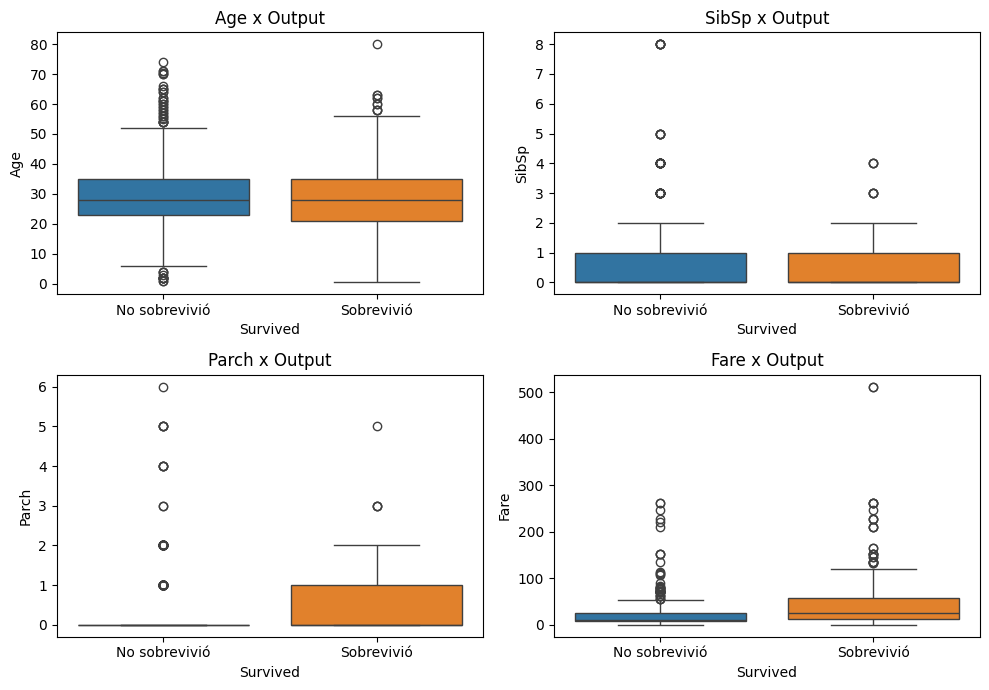

In [70]:
numerical_vars = ['Age', 'SibSp', 'Parch', 'Fare']

# Configurar la figura para los boxplots
plt.figure(figsize=(10, 7))

# Crear boxplots para cada variable cuantitativa
for i, var in enumerate(numerical_vars, 1):
    plt.subplot(2, 2, i)  # 2 filas, 2 columnas
    sns.boxplot(x='Survived', y=var, data=datos, hue='Survived')
    plt.title(f'{var} x Output')
    plt.ylabel(var)

plt.tight_layout()
plt.show()

* **Parch** muestra la diferencia más clara: los pasajeros que sobrevivieron tienden a tener más familiares que los que fallecieron.

* **Fare** también muestra diferencias pero menos apreciables: los viajeros que se salvaron pagaron ligeralmente más por sus tickets.

* Las variables **Age** y **SibSp** muestran diferencias menores entre los grupos, lo que sugiere que podrían ser predictores menos útiles para distinguir la presencia de enfermedad cardíaca.

In [71]:
for var in numerical_vars:
    print(f"\nAnálisis para {var}:")
    print("-" * 50)

    # Separar los grupos usando output
    grupo_0 = datos[datos['Survived'] == 'No sobrevivió'][var]
    grupo_1 = datos[datos['Survived'] == 'Sobrevivió'][var]

    # Test de Shapiro-Wilk para cada grupo
    _, p_shapiro_0 = stats.shapiro(grupo_0)
    _, p_shapiro_1 = stats.shapiro(grupo_1)

    print(f"\nTest de Normalidad (Shapiro-Wilk):")
    print(f"Grupo No Sobrevivió: p-valor = {p_shapiro_0:.4f}")
    print(f"Grupo Sobrevivió: p-valor = {p_shapiro_1:.4f}")

    # T-test
    t_stat, p_t = stats.ttest_ind(grupo_0, grupo_1)

    # Mann-Whitney
    u_stat, p_mw = stats.mannwhitneyu(grupo_0, grupo_1, alternative='two-sided')

    print(f"\nTest t de Student:")
    print(f"t = {t_stat:.4f}, p-valor = {p_t:.4f}")

    print(f"\nTest de Mann-Whitney:")
    print(f"U = {u_stat:.4f}, p-valor = {p_mw:.4f}")


Análisis para Age:
--------------------------------------------------

Test de Normalidad (Shapiro-Wilk):
Grupo No Sobrevivió: p-valor = 0.0000
Grupo Sobrevivió: p-valor = 0.0000

Test t de Student:
t = 1.9612, p-valor = 0.0502

Test de Mann-Whitney:
U = 97670.5000, p-valor = 0.2524

Análisis para SibSp:
--------------------------------------------------

Test de Normalidad (Shapiro-Wilk):
Grupo No Sobrevivió: p-valor = 0.0000
Grupo Sobrevivió: p-valor = 0.0000

Test t de Student:
t = 0.8776, p-valor = 0.3804

Test de Mann-Whitney:
U = 85084.0000, p-valor = 0.0061

Análisis para Parch:
--------------------------------------------------

Test de Normalidad (Shapiro-Wilk):
Grupo No Sobrevivió: p-valor = 0.0000
Grupo Sobrevivió: p-valor = 0.0000

Test t de Student:
t = -2.5223, p-valor = 0.0118

Test de Mann-Whitney:
U = 81741.5000, p-valor = 0.0000

Análisis para Fare:
--------------------------------------------------

Test de Normalidad (Shapiro-Wilk):
Grupo No Sobrevivió: p-valor = 0

De los resultados, los aspectos más relevantes son:

* Todas las variables no siguen una distribución normal (p-valor Shapiro < 0.05), por lo que debemos fijarnos principalmente en el test de Mann-Whitney.

* Hay diferencias altamente significativas (p-valor < 0.05) entre grupos Sobrevivieron/No Sobrevivieron en todas las variables excepto Age, siendo las más destacadas:

   - 'Parch': p < 0.0001
   - 'Fare': p < 0.0001

Esto confirma estadísticamente lo que observamos en los boxplots, siendo las variables las más discriminativas entre grupos.

### Análisis de correlaciones

Vamos a obtener un heatmap que muestre la matriz de correlaciones entre las variables cuantitativas del dataset.

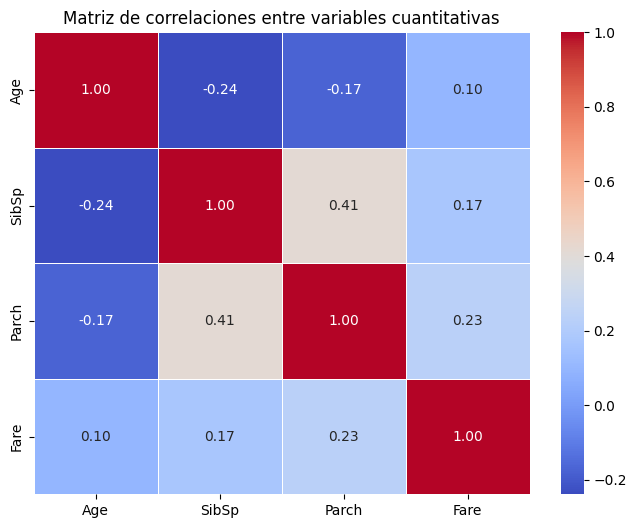

In [72]:
numerical_vars = ['Age', 'SibSp', 'Parch', 'Fare']

# Calcular la matriz de correlaciones para las variables cuantitativas
correlation_matrix = datos[numerical_vars].corr()

# Crear heatmap para visualizar las correlaciones
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Matriz de correlaciones entre variables cuantitativas")
plt.show()

En general, no tenemos correlaciones que lleguen al 0,5.

Esto no significa que no sean útiles, pero debemos ser cuidadosos en su uso. A través de técnicas como el análisis del Factor de Inflación de la Varianza (VIF) o pruebas de multicolinealidad, podemos decidir si estas variables realmente mejoran el modelo o si deben ser descartadas. Es esencial validar su impacto en el desempeño predictivo y evitar incluirlas todas de forma automática.

### Pairplots

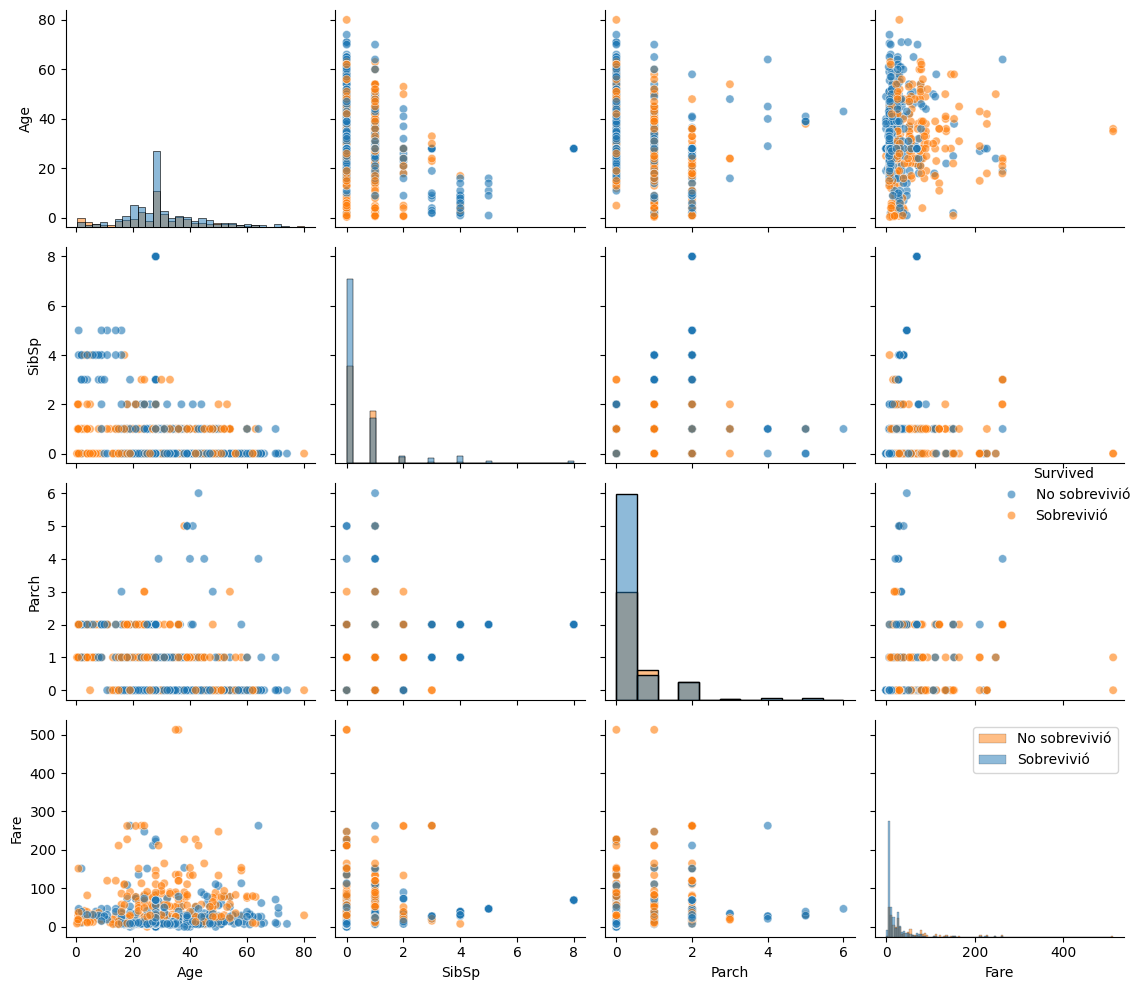

In [73]:
sns.pairplot(datos, vars=numerical_vars, hue='Survived',
             diag_kind='hist', plot_kws={'alpha': 0.6})
plt.legend(labels=['No sobrevivió', 'Sobrevivió'])
plt.tight_layout()
plt.show()

Analizando el pairplot, los aspectos más relevantes son:

* Correlaciones:
  - Las que implican a las variables SibSp y Parch no son fácilmente interpretables por ser discretas. Podríamos destacar las variables Parch y Age.
  - Las variables Age y Fare muestran correlación por formar una recta.

* Distribuciones:
  * La mayoría de variables muestran distribuciones asimétricas a la derecha, confirmando lo que vimos en los tests de normalidad.
  * 'Age' muestra una distribución simétrica luego no presenta sesgo.

## 7. Análisis Multivariante


### Regresión Logística

La Regresión Logística nos permitirá:

* Modelar la probabilidad de sobrevivir usando todas las variables (categóricas y cuantitativas).
* Obtener los odds ratios para interpretar la importancia de cada variable.
* Ver qué variables son estadísticamente significativas para predecir la supervivencia.

In [74]:
categoricas_vars = ['Pclass', 'Sex', 'Embarked', 'Age_group', 'Is_alone']
numerical_vars = ['Age', 'SibSp', 'Parch', 'Fare']

# Preparar los datos
datos['Survived_cat'] = (datos['Survived'] == 'Sobrevivió').astype(int)

# Separar variables
X_cat = pd.get_dummies(datos[categoricas_vars], drop_first=True)
X_num = datos[numerical_vars].copy()

# Escalar variables numéricas
scaler = StandardScaler()
X_num_scaled = pd.DataFrame(
    scaler.fit_transform(X_num),
    columns=X_num.columns,
    index=X_num.index
)

# Unir variables escaladas y dummy manteniendo el índice
X = pd.concat([X_num_scaled, X_cat], axis=1)
y = datos['Survived_cat']

# Convertir a numpy arrays
X_np = np.asarray(X, dtype=float)
y_np = np.asarray(y, dtype=float)

# Ajustar modelo con statsmodels
X_with_const = sm.add_constant(X_np)
modelo = sm.Logit(y_np, X_with_const)
resultados = modelo.fit()

# Crear dataframe con resultados
coef_df = pd.DataFrame({
    'Variable': X.columns,
    'Coeficiente': resultados.params[1:],  # Excluimos la constante
    'Odds_Ratio': np.exp(resultados.params[1:]),
    'P_valor': resultados.pvalues[1:]  # Excluimos la constante
})

# Filtrar significativas y ordenar por p-valor
coef_df_sig = coef_df[coef_df['P_valor'] < 0.05].sort_values('P_valor', ascending=True)

print("Variables significativas ordenadas por p-valor:")
print(coef_df_sig)

Optimization terminated successfully.
         Current function value: 0.429134
         Iterations 7
Variables significativas ordenadas por p-valor:
                  Variable  Coeficiente  Odds_Ratio       P_valor
6                 Sex_male    -2.714297    0.066252  4.580144e-39
5           Pclass_3ªclase    -1.932994    0.144714  3.084647e-10
1                    SibSp    -0.731965    0.480963  2.920211e-05
4           Pclass_2ªclase    -0.873830    0.417350  4.262320e-03
13      Is_alone_Not Alone     0.762401    2.143417  8.484230e-03
2                    Parch    -0.309587    0.733750  8.648781e-03
10  Age_group_Joven Adulto    -1.527471    0.217084  1.148887e-02


Este resultado nos muestra las variables significativas (p < 0.05) ordenadas por su p-valor, lo que indica su poder discriminativo.

Interpretando los resultados:

Las variables Sex_male, Pclass_3ªclase, SibSp, Pclass_2ªclase, Parch, Age_group_Joven_Adulto y Is_alone_Not_Alone tienen p-valores < 0.05, lo que significa que todas son estadísticamente significativas en la predicción de la supervivencia.

- La variable Is_alone_Not_Alone es un factor protector fuerte. Es la que posee el coeficiente y odd ratio más alto. Luego tiene un impacto significativo en la supervivencia de los pasajeros del titanic. Presenta un odd ratio de 2.14, por lo que haber viajado acompañado aumenta 2 veces la probabilidad de sobrevivir.
- Las variables Sex_male, Pclass_cat_3ªclase y Age_group_Joven_Adulto son factores de riesgo fuertes. Poseen los coeficientes y odd ratios más bajos, luego tendrán un impacto significativo en la no supervivencia.
  - La variable Sex_male presenta el odd ratio más bajo de 0.06, por lo que ser hombre, disminuye un 94% la probabilidad de sobrevivir en el barco.
  - La variable Pclass_cat_3ªclase presenta un odd ratio de 0.14, por lo que pertenecer a tercera clase, la probabilidad de sobrevivir disminuye un 86% en el barco.
  - La variable Age_group_Joven_Adulto presenta el odd ratio más bajo de 0.22, por lo que pertenecer al grupo de edad "Joven Aulto" dismunuye un 78% la probabilidad de sobrevivir.

- Aparte, las variables Pclass_cat_2ªclase, SibSp y Parch son factores de riesgo leves. Presentan odd ratios de 0.41, 0'48 y 0'73, por lo que disminuyen la probabilidad de sobrevivir un 59%, un 52% y un 27%, respectivamente.

Este análisis confirma y cuantifica lo que vimos en los análisis univariantes previos (Mann-Whitney y Chi-cuadrado), pero ahora en un contexto multivariante.

### Análisis Discriminante Lineal

El Análisis Discriminante Lineal (LDA) en este contexto nos permitirá:

* Encontrar una combinación lineal de variables que mejor separe los grupos Sobrevivió/No sobrevivió.
* Ver qué variables contribuyen más a esta separación mediante los coeficientes discriminantes.
* Obtener las probabilidades de clasificación basadas en supuestos de normalidad (a diferencia de la regresión logística).

In [75]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

categoricas_vars = ['Pclass', 'Sex', 'Embarked', 'Age_group', 'Is_alone']
numerical_vars = ['Age', 'SibSp', 'Parch', 'Fare']

# Preparar los datos
datos['Survived_cat'] = (datos['Survived'] == 'Sobrevivió').astype(int)

# Separar variables
X_cat = pd.get_dummies(datos[categoricas_vars], drop_first=True)
X_num = datos[numerical_vars].copy()

# Escalar variables numéricas
scaler = StandardScaler()
X_num_scaled = pd.DataFrame(
    scaler.fit_transform(X_num),
    columns=X_num.columns,
    index=X_num.index
)

# Unir variables escaladas y dummy
X = pd.concat([X_num_scaled, X_cat], axis=1)
y = datos['Survived_cat']

# Ajustar LDA
lda = LinearDiscriminantAnalysis()
lda.fit(X, y)

# Obtener coeficientes discriminantes y varianza explicada
coef_df = pd.DataFrame({
    'Variable': X.columns,
    'Coef_discriminante': lda.coef_[0]
})
coef_df['Abs_Coef'] = abs(coef_df['Coef_discriminante'])
coef_df_sorted = coef_df.sort_values('Abs_Coef', ascending=False)

print("Ratio de varianza explicada:", lda.explained_variance_ratio_)
print("\nCoeficientes discriminantes ordenados por importancia:")
print(coef_df_sorted)

# Obtener las puntuaciones discriminantes
scores = lda.transform(X)

# Score medio por grupo
print("\nPuntuaciones discriminantes medias por grupo:")
for group in [0, 1]:
    print(f"Grupo {group}:", scores[y == group].mean())

Ratio de varianza explicada: [1.]

Coeficientes discriminantes ordenados por importancia:
                  Variable  Coef_discriminante  Abs_Coef
6                 Sex_male           -3.566626  3.566626
5           Pclass_3ªclase           -2.124295  2.124295
10  Age_group_Joven Adulto           -1.541890  1.541890
12        Age_group_Senior           -1.312722  1.312722
9   Age_group_Adolescentes           -1.222801  1.222801
11        Age_group_Adulto           -1.137797  1.137797
4           Pclass_2ªclase           -0.948611  0.948611
13      Is_alone_Not Alone            0.649692  0.649692
1                    SibSp           -0.544992  0.544992
8               Embarked_S           -0.427081  0.427081
0                      Age           -0.413530  0.413530
2                    Parch           -0.328077  0.328077
3                     Fare            0.172262  0.172262
7               Embarked_Q            0.084474  0.084474

Puntuaciones discriminantes medias por grupo:
Grupo 0:

Los resultados del LDA muestran:

* Capacidad discriminativa general:
   - Ratio de varianza explicada = 1.0, indica que la función discriminante explica toda la variabilidad entre grupos.
   - Las puntuaciones medias de los grupos (-0.66 vs 1.06) muestran una moderada separación.

* Variables más importantes para la discriminación (mayores coeficientes en valor absoluto):
   - 'Sex_male' (-3.57): ser hombre.
   - 'Pclass_3ªclase' (-2.12): viajar en 3ª clase.
   - 'Age_group_Joven_Adulto' (-1.54): pertenecer al grupo Joven Adulto.
   - 'Age_group_Senior' (-1.31): pertenecer al grupo Senior.
   - 'Age_group_Adolescentes' (-1.222801): pertenecer al grupo Adolescentes.
   - 'Age_group_Adulto' (-1.137797): pertenecer al grupo Adulto
   - 'Pclass_2ªclase' (-0.948611): viajar en 2ª clase.

* Variables menos discriminantes:
   - 'Is_alone_Not Alone' (0.649692)
   - 'SibSp' (-0.544992)
   - 'Embarked_S' (-0.427081)
   - 'Age' (-0.413530)
   - 'Parch' (-0.328077)
   - 'Fare' (0.172262)
   - 'Embarked_Q' (0.084474)

* Ser hombre, pertenecer a 3ª clase, y pertenecer al grupo Joven Adulto ('Sex_male', 'Pclass_3ªclase' y 'Age_group_Joven_Adulto') siguen siendo clave en ambos modelos, lo que refuerza su importancia en la predicción de la supervivencia.

* Pertenecer a 2ª clase, el número de hermanos/cónyugues y el número de padres/hijos (Pclass_cat_2ªclase, SibSp y Parch) también son relevantes en ambos enfoques.

* Pertenecer al grupo de edad Senior, Adolescente y Adulto ('Age_group_Senior', 'Age_group_Adolescentes' y 'Age_group_Adulto') son muy influyentes en LDA, pero no en la regresión logística. Esto sugiere que estas variables pueden ayudar a separar los grupos de pacientes, aunque no sean las mejores predictores probabilísticas.

## Conclusiones del EDA

Las conclusiones más importantes de nuestro EDA debemos recogerlas en un punto final.

**Estructura y calidad de los datos**

* Se analizaron 891 observaciones con valores faltantes.
* Se rellenaron los valores ausentes con la mediana y la moda según si eran numéricas o categóricas.
* Se eliminaron las variables 'Name', 'PassengerId' y 'Ticket' debido a la ausencia de información relevante.
* Se redefinieron variables categóricas y se crearon nuevas variables (Age_group y Is_alone), relacionadas con el grupo deedad al que pertenecen y la compañia que tenían en el barco.

**Análisis descriptivo y distribución de variables**

* La mayoría de los pacientes son hombres (64.7%).
* La variable objetivo (Survived) está balanceada: un 61.6% no sobrevivieron.
* La clase más representada es la tercera (55.1%), seguida de la primera (24.2%).
* La mayoría embarcaron en Southampton (72.5%) y pertenecían al grupo de edad Joven Adulto o Adulto.
* La variable Is_alone está balanceada: un 60.2 fueron solos.
* La media de edad era de 30 años.
* El 75% iban con a lo sumo un padre/hijo.
* La media pagada por el ticket era de 34 libras.

**Relaciones entre variables (Análisis Bivariado y Multivariado)**

* Se encontraron asociaciones altamente significativas entre la supervivencia y las variables Pclass, Sex, Embarked, Age_group y Is_alone.
* En cuanto a variables numéricas, SibSp, Parch y Fare mostraron diferencias claras entre sobrevivir y no sobrevivir.
* La regresión logística identificó Is_alone_Not_Alone, Sex_male, Pclass_cat_3ªclase y Age_group_Joven_Adulto como los predictores más importantes (el primero es protector y el resto de riesgo).

## Guardado del dataframe

In [76]:
datos.to_parquet('titanic.parquet', index=False)

# Para cargarlo
titanic = pd.read_parquet('titanic.parquet')
titanic.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,Age_group,Is_alone,Survived_cat
0,No sobrevivió,3ªclase,male,22.0,1,0,7.2500,S,Joven Adulto,Not Alone,0
1,Sobrevivió,1ªclase,female,38.0,1,0,71.2833,C,Adulto,Not Alone,1
2,Sobrevivió,3ªclase,female,26.0,0,0,7.9250,S,Joven Adulto,Alone,1
3,Sobrevivió,1ªclase,female,35.0,1,0,53.1000,S,Adulto,Not Alone,1
4,No sobrevivió,3ªclase,male,35.0,0,0,8.0500,S,Adulto,Alone,0


In [77]:
# Guardar archivos en Drive
ruta_drive = '/content/drive/MyDrive/mi_carpeta/'

import os

# Crear la carpeta si no existe
if not os.path.exists(ruta_drive):
    os.makedirs(ruta_drive)
    print(f"Carpeta '{ruta_drive}' creada con éxito")
else:
    print(f"La carpeta '{ruta_drive}' ya existe")

# Crear una subcarpeta
ruta_subcarpeta = "/content/drive/MyDrive/mi_carpeta/subcarpeta"
os.makedirs(ruta_subcarpeta, exist_ok=True) # exist_ok=True evita error si ya existe

!jupyter nbconvert --to html ruta_drive

La carpeta '/content/drive/MyDrive/mi_carpeta/' ya existe
[NbConvertApp] WARNING | pattern 'ruta_drive' matched no files
This application is used to convert notebook files (*.ipynb)
        to various other formats.


Options
The options below are convenience aliases to configurable class-options,
as listed in the "Equivalent to" description-line of the aliases.
To see all configurable class-options for some <cmd>, use:
    <cmd> --help-all

--debug
    set log level to logging.DEBUG (maximize logging output)
    Equivalent to: [--Application.log_level=10]
--show-config
    Show the application's configuration (human-readable format)
    Equivalent to: [--Application.show_config=True]
--show-config-json
    Show the application's configuration (json format)
    Equivalent to: [--Application.show_config_json=True]
--generate-config
    generate default config file
    Equivalent to: [--JupyterApp.generate_config=True]
-y
    Answer yes to any questions instead of prompting.
    Equivale